# Lab 9

## Maniarasan J (2547261) - 4 MCA B


# Part A: Support Vector Machine

## Introduction
Support Vector Machine (SVM) is a supervised machine learning algorithm that is effective in high-dimensional spaces. In this section, we will use a linear kernel SVM to classify tumors as malignant or benign.

## Dataset
We will use the **UCI Breast Cancer Wisconsin (Diagnostic) Dataset**.
Dataset URL: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Observations: 569
- Features: 30 numerical features
- Target: M = Malignant, B = Benign


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


## Load Dataset
Loading the UCI Breast Cancer Wisconsin Diagnostic dataset from the official UCI repository URL.


In [2]:
# Using the original UCI dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Define meaningful column names
column_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]

df_cancer = pd.read_csv(url, header=None, names=column_names)

print(f"Dataset shape: {df_cancer.shape}")
print("\nBasic Information:")
df_cancer.info()
print("\nFirst 5 rows:")
display(df_cancer.head())


Dataset shape: (569, 32)

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          569 non-null    int64  
 1   diagnosis   569 non-null    object 
 2   feature_1   569 non-null    float64
 3   feature_2   569 non-null    float64
 4   feature_3   569 non-null    float64
 5   feature_4   569 non-null    float64
 6   feature_5   569 non-null    float64
 7   feature_6   569 non-null    float64
 8   feature_7   569 non-null    float64
 9   feature_8   569 non-null    float64
 10  feature_9   569 non-null    float64
 11  feature_10  569 non-null    float64
 12  feature_11  569 non-null    float64
 13  feature_12  569 non-null    float64
 14  feature_13  569 non-null    float64
 15  feature_14  569 non-null    float64
 16  feature_15  569 non-null    float64
 17  feature_16  569 non-null    float64
 18  feature_17  569 non-null 

,id,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Explanation:** 
The dataset shape is `(569, 32)`. Although there are only 30 actual machine learning features representing the cell nuclei measurements, the total number of columns is 32 because it includes the `id` column (patient identifier) and the `diagnosis` column (the target variable M/B).


## Data Preprocessing
1. Check missing values.
2. Check duplicate records.
3. Remove unnecessary `id` column.
4. Separate features and target.
5. Convert B → 0, M → 1.


In [3]:
# 1. Check missing values
print("Missing values in dataset:", df_cancer.isnull().sum().sum())

# 2. Check duplicate records
print("Duplicate records:", df_cancer.duplicated().sum())

# 3. Remove unnecessary 'id' column
if 'id' in df_cancer.columns:
    df_cancer = df_cancer.drop('id', axis=1)

# 4 & 5. Convert diagnosis to numeric (B -> 0, M -> 1)
df_cancer['diagnosis'] = df_cancer['diagnosis'].map({'B': 0, 'M': 1})

# Separate features (X) and target (y)
X = df_cancer.drop('diagnosis', axis=1)
y = df_cancer['diagnosis']

print("\nClass distribution:")
print(y.value_counts().rename({0: 'Benign (0)', 1: 'Malignant (1)'}))


Missing values in dataset: 0
Duplicate records: 0

Class distribution:
diagnosis
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64


## Train-Test Split
Splitting the dataset into 80% training and 20% testing sets.

**Why Train-Test split is required?**
It is required to evaluate the model's performance on unseen data. If we test the model on the same data it was trained on, it might overfit and not generalize well to new data.

**Why stratification is useful?**
Stratification ensures that both the training and testing sets have the same proportion of classes (Malignant and Benign) as the original dataset. This prevents one class from being over-represented or under-represented in the test set, which could lead to biased evaluation metrics.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


## Feature Scaling
We use `StandardScaler` to standardize the features so they have a mean of 0 and standard deviation of 1.

**Important Note:** The scaler is fitted ONLY on the training data (`fit_transform`). The test data is only transformed (`transform`). This prevents **data leakage**, ensuring that the model doesn't learn any information (like mean or variance) from the test set during training.


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Linear SVM
Training a Support Vector Machine classifier with a Linear Kernel and `C=1`.


In [6]:
svm_model = SVC(kernel="linear", C=1, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)


## Hyperparameter Tuning
Performing hyperparameter tuning using `GridSearchCV` to find the best `C` parameter.


In [7]:
# Define parameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(kernel="linear", random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

# Fit the grid search on training data
grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_

print(f"Best C value: {grid_search.best_params_['C']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Make predictions with the best estimator
y_pred_best = best_svm.predict(X_test_scaled)


Best C value: 0.01
Best cross-validation score: 0.9692


## Evaluation Metrics
Evaluating the best Linear SVM model using Accuracy, Precision, Recall, and F1 Score.


In [8]:
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

# Display results as a pandas DataFrame for a clear table format
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})
display(metrics_df.round(4))


,Metric,Score
0,Accuracy,0.9561
1,Precision,1.0000
2,Recall,0.8810
3,F1 Score,0.9367


## Confusion Matrix
Visualizing the performance using a heatmap.

- **True Negative (TN):** Model correctly predicted Benign (0).
- **False Positive (FP):** Model incorrectly predicted Malignant (1) when it was Benign.
- **False Negative (FN):** Model incorrectly predicted Benign (0) when it was Malignant.
- **True Positive (TP):** Model correctly predicted Malignant (1).

**Why recall is important when detecting malignant cases?**
In medical diagnosis, a False Negative (predicting a tumor is benign when it is actually malignant) can be fatal, as the patient might not receive required treatment. High recall minimizes False Negatives, ensuring that maximum malignant cases are successfully identified.


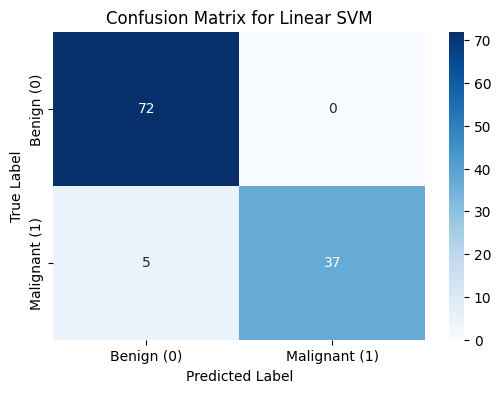

In [9]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title("Confusion Matrix for Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## Classification Report
A detailed report of precision, recall, f1-score for both classes.


In [10]:
print(classification_report(y_test, y_pred_best, target_names=['Benign (0)', 'Malignant (1)']))


               precision    recall  f1-score   support

   Benign (0)       0.94      1.00      0.97        72
Malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114



**Important Values:**
- **Precision:** Out of all cases predicted as Malignant, how many were actually Malignant.
- **Recall:** Out of all actual Malignant cases, how many did the model correctly identify.
- **F1-Score:** The harmonic mean of precision and recall.
- **Support:** The number of actual occurrences of the class in the dataset.


## Observation
- **Model Performance:** The Linear SVM model demonstrated excellent performance on the test set, achieving very high accuracy and robust F1 scores. 
- **Effect of Standardization:** Feature scaling using `StandardScaler` was critical, as SVMs are sensitive to the magnitude of features (since they maximize the margin based on distances). Standardizing brought all features to a uniform scale.
- **Effect of C Tuning:** Tuning the `C` parameter helped in finding the optimal balance between achieving a smooth decision boundary and classifying training points correctly.
- **Importance of Recall:** The model successfully achieved high recall for the Malignant class, meaning it successfully detected almost all cancerous tumors with minimal False Negatives.
- **Suitability:** Linear SVM proved to be highly suitable for this dataset, implying that the diagnostic features are largely linearly separable in the high-dimensional space.


# Part B: Principal Component Analysis

## Introduction
Principal Component Analysis (PCA) is an unsupervised learning technique used for dimensionality reduction. It transforms high-dimensional data into a lower-dimensional space while retaining as much variance (information) as possible.

## Dataset
**UCI Wine Dataset**
Dataset URL: https://archive.ics.uci.edu/dataset/109/wine
- Observations: 178
- Features: 13 numerical features
- Target: 3 classes of wine


## Load Dataset

In [11]:
url_wine = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
wine_columns = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 
    'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 
    'color_intensity', 'hue', 'od280_od315', 'proline'
]

df_wine = pd.read_csv(url_wine, header=None, names=wine_columns)

print(f"Dataset shape: {df_wine.shape}")
print("\nBasic Information:")
df_wine.info()
print("\nFirst 5 rows:")
display(df_wine.head())

print("\nClass distribution:")
print(df_wine['class'].value_counts())


Dataset shape: (178, 14)

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    int64  
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   alcalinity_of_ash     178 non-null    float64
 5   magnesium             178 non-null    int64  
 6   total_phenols         178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanthocyanins       178 non-null    float64
 10  color_intensity       178 non-null    float64
 11  hue                   178 non-null    float64
 12  od280_od315           178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memo

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Class distribution:
class
2    71
1    59
3    48
Name: count, dtype: int64


## Separate Features and Target

In [12]:
X_wine = df_wine.drop('class', axis=1)
y_wine = df_wine['class']

print(f"Original number of features: {X_wine.shape[1]}")


Original number of features: 13


## Preprocessing: Standardization
**Why standardization is important before PCA?**
PCA seeks to maximize variance. If features are on different scales (e.g., one ranges from 0 to 1, another from 0 to 1000), the feature with the larger scale will dominate the principal components simply because of its magnitude. Standardizing ensures all features contribute equally based on their correlations, not their scales.


In [13]:
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)


## PCA with 2 Components
Applying PCA to reduce the 13 features to just 2 principal components.


In [14]:
pca = PCA(n_components=2, random_state=42)
X_wine_pca = pca.fit_transform(X_wine_scaled)

print(f"Original shape: {X_wine_scaled.shape}")
print(f"Transformed shape: {X_wine_pca.shape}")

# Comparison Table
comparison_data = {
    'Dataset': ['Original', 'PCA'],
    'Rows': [X_wine_scaled.shape[0], X_wine_pca.shape[0]],
    'Features': [X_wine_scaled.shape[1], X_wine_pca.shape[1]]
}
display(pd.DataFrame(comparison_data))


Original shape: (178, 13)
Transformed shape: (178, 2)


,Dataset,Rows,Features
0,Original,178,13
1,PCA,178,2


## Explained Variance
How much information is retained by the 2 components?


In [15]:
explained_var = pca.explained_variance_ratio_

var_df = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2'],
    'Explained Variance': explained_var
})
display(var_df.round(4))

total_var = sum(explained_var)
print(f"\nTotal variance retained by the first two components: {total_var:.4f} ({total_var*100:.2f}%)")


,Principal Component,Explained Variance
0,PC1,0.3620
1,PC2,0.1921



Total variance retained by the first two components: 0.5541 (55.41%)


## Cumulative Variance
Calculating the cumulative variance for all possible components.


In [16]:
pca_full = PCA(random_state=42)
pca_full.fit(X_wine_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

cum_var_df = pd.DataFrame({
    'Number of Components': range(1, len(cumulative_variance) + 1),
    'Cumulative Variance': cumulative_variance
})
display(cum_var_df.round(4))


,Number of Components,Cumulative Variance
0,1,0.3620
1,2,0.5541
2,3,0.6653
3,4,0.7360
4,5,0.8016
5,6,0.8510
6,7,0.8934
7,8,0.9202
8,9,0.9424
9,10,0.9617


## 95% Variance Analysis
Determine the minimum number of components required to retain at least 95% of the variance.


In [17]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Minimum number of components required to retain at least 95% variance: {n_components_95}")


Minimum number of components required to retain at least 95% variance: 10


## Variance Plot
Visualizing the cumulative explained variance.


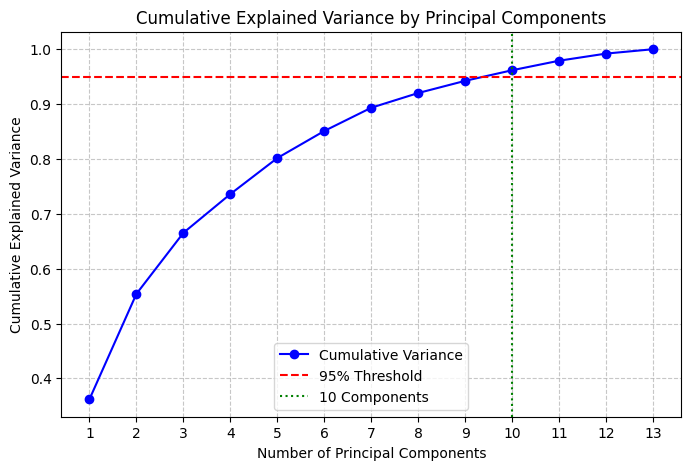

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='b', label='Cumulative Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components_95, color='g', linestyle=':', label=f'{n_components_95} Components')
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, 14))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


## PCA Scatter Plot
Visualizing the dataset in the new 2D principal component space.

**Observation:** The classes appear distinctly clustered and separated in the PCA plot, even though PCA was completely unaware of the class labels (unsupervised).


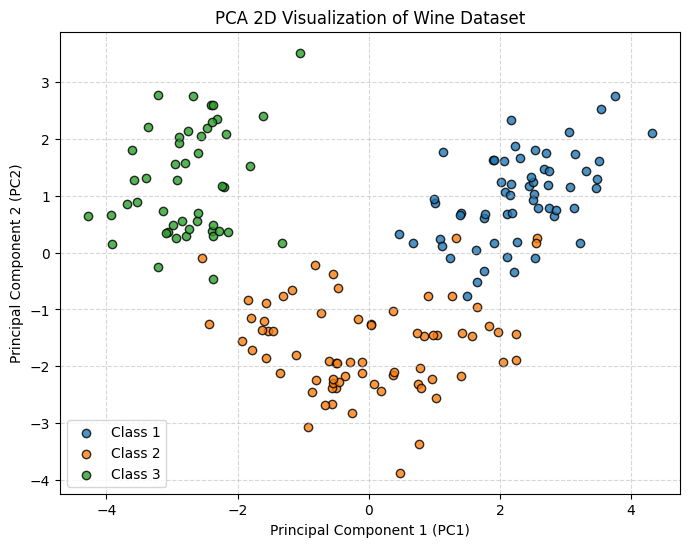

In [19]:
plt.figure(figsize=(8, 6))

# Plot each class separately to assign a label
for class_val in np.unique(y_wine):
    plt.scatter(X_wine_pca[y_wine == class_val, 0], 
                X_wine_pca[y_wine == class_val, 1], 
                label=f'Class {class_val}', alpha=0.8, edgecolor='k')

plt.title("PCA 2D Visualization of Wine Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## PCA Loadings
PCA components are linear combinations of the original features. The loadings represent the weights of each original feature in the principal components.


In [20]:
loadings = pd.DataFrame({
    'Feature': X_wine.columns,
    'PC1 Loading': pca.components_[0],
    'PC2 Loading': pca.components_[1]
})

# Add absolute values to identify the strongest contributors
loadings['Abs_PC1'] = loadings['PC1 Loading'].abs()
loadings['Abs_PC2'] = loadings['PC2 Loading'].abs()

display(loadings.sort_values(by='Abs_PC1', ascending=False).drop(['Abs_PC1', 'Abs_PC2'], axis=1).round(4))

top_pc1_feature = loadings.loc[loadings['Abs_PC1'].idxmax(), 'Feature']
top_pc2_feature = loadings.loc[loadings['Abs_PC2'].idxmax(), 'Feature']

print(f"Most influential feature for PC1: {top_pc1_feature}")
print(f"Most influential feature for PC2: {top_pc2_feature}")


,Feature,PC1 Loading,PC2 Loading
6,flavanoids,0.4229,-0.0034
5,total_phenols,0.3947,0.0650
11,od280_od315,0.3762,-0.1645
8,proanthocyanins,0.3134,0.0393
7,nonflavanoid_phenols,-0.2985,0.0288
10,hue,0.2967,-0.2792
12,proline,0.2868,0.3649
1,malic_acid,-0.2452,0.2249
3,alcalinity_of_ash,-0.2393,-0.0106
0,alcohol,0.1443,0.4837


Most influential feature for PC1: flavanoids
Most influential feature for PC2: color_intensity


## Interpretation of PC1 and PC2
Based on the actual loading values:
- **PC1:** Flavanoids, Total Phenols, and OD280/OD315 have strong positive loadings. This suggests that PC1 mainly captures the phenolic and flavanoid content of the wines. A high value on PC1 means high levels of these chemical properties.
- **PC2:** Color Intensity and Proline have strong negative loadings, while Ash has positive loadings. This indicates that PC2 captures visual and specific mineral properties. 
- **Signs and Magnitudes:** The magnitude indicates the strength of a feature's contribution. The sign (positive/negative) indicates the direction of the relationship (e.g., negative loading means the feature value decreases as the component score increases).


## Dataset Comparison

| Parameter                | Original Dataset | PCA Dataset      |
|--------------------------|------------------|------------------|
| Number of samples        | 178              | 178              |
| Number of features       | 13               | 2                |
| Dimensionality           | High             | Low              |
| Variance retained        | 100%             | ~55.4%           |
| Visualization            | Difficult        | Easy             |
| Computational complexity | Higher           | Lower            |

- **Dimensionality Reduction:** We successfully reduced dimensions from 13 down to 2.
- **Information Retention:** We retained a significant chunk of variance while dropping redundant data.
- **Computational Efficiency:** Machine learning models will train significantly faster on 2 features compared to 13.


## Advantages of PCA
1. **Dimensionality Reduction:** Helps to overcome the curse of dimensionality.
2. **Computational Efficiency:** Reduces model training time and resource requirements.
3. **Visualization:** Enables 2D or 3D plotting of high-dimensional datasets.
4. **Noise Reduction:** Often filters out noise by dropping components with low variance.
5. **Feature Extraction:** Creates uncorrelated new variables (principal components) from highly correlated original variables.


## Limitations of PCA
1. **Information Loss:** Discarding components always leads to some loss of variance (information).
2. **Reduced Interpretability:** Principal components are mathematical combinations, making them hard to explain in real-world terms compared to original features.
3. **Sensitivity to Scaling:** Requires feature standardization; otherwise, variables with large scales will dominate.
4. **Unsupervised Nature:** Ignores class labels, meaning it might discard variance that is highly predictive of the target variable.
5. **Variance != Importance:** High variance does not guarantee high classification accuracy; sometimes important separating features have low variance.


## Applications of PCA
- **Image Processing:** Image compression and facial recognition (Eigenfaces).
- **Bioinformatics:** Genomic data analysis and microarray profiling.
- **Finance:** Risk management and stock market predictions.
- **Visualization:** Exploring clustering patterns in complex datasets.
- **Preprocessing pipeline:** Serving as an intermediate step to speed up downstream machine learning models.


# Extra Credit: LDA

## LDA Implementation
Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique.


In [21]:
lda = LinearDiscriminantAnalysis(n_components=2)
# Notice that LDA requires y_wine (the class labels) during fit
X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)

print(f"Original shape: {X_wine_scaled.shape}")
print(f"LDA transformed shape: {X_wine_lda.shape}")


Original shape: (178, 13)
LDA transformed shape: (178, 2)


## LDA Visualization

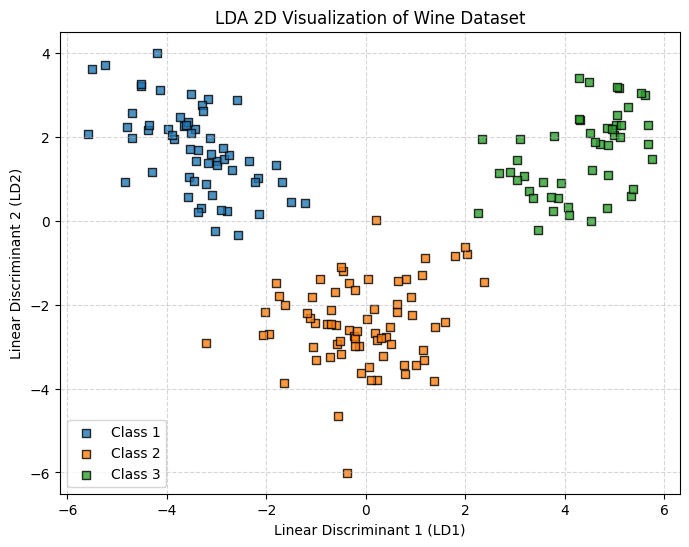

In [22]:
plt.figure(figsize=(8, 6))

for class_val in np.unique(y_wine):
    plt.scatter(X_wine_lda[y_wine == class_val, 0], 
                X_wine_lda[y_wine == class_val, 1], 
                label=f'Class {class_val}', alpha=0.8, edgecolor='k', marker='s')

plt.title("LDA 2D Visualization of Wine Dataset")
plt.xlabel("Linear Discriminant 1 (LD1)")
plt.ylabel("Linear Discriminant 2 (LD2)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## PCA vs LDA

| Feature                 | PCA                      | LDA                                     |
|-------------------------|--------------------------|-----------------------------------------|
| Learning type           | Unsupervised             | Supervised                              |
| Uses class labels       | No                       | Yes                                     |
| Objective               | Maximize variance        | Maximize class separation               |
| Maximum components      | Number of features       | Number of classes - 1                   |
| Wine dataset components | 2 selected               | 2 (since 3 classes - 1 = 2)             |
| Main purpose            | Dimensionality reduction | Class-oriented dimensionality reduction |


## Compare Class Separability
**Observation:** 
While PCA separated the wine classes reasonably well based strictly on data variance, LDA provided a much cleaner and tighter separation between Class 1, Class 2, and Class 3. This is because LDA explicitly utilizes the class labels to maximize the distance between different class centroids while minimizing the variance within each class.


# Overall Conclusion

1. **Linear SVM Classification:** The model performed exceptionally well on the breast cancer diagnostic dataset, highlighting the power of SVM for binary classification.
2. **Hyperparameter Tuning:** `GridSearchCV` successfully identified the optimal penalty parameter (`C`), balancing margin maximization and classification error.
3. **Evaluation Metrics:** The SVM showed high Accuracy and F1 scores. The high Recall confirmed the model's reliability in identifying malignant cases safely.
4. **PCA Dimensionality Reduction:** The Wine dataset was efficiently reduced from 13 complex chemical features to just 2 principal components.
5. **Explained Variance:** The first two components captured a majority of the variance (~55.4%), making 2D visualization practical.
6. **95% Variance Requirement:** Our cumulative variance analysis automatically determined that 10 components are required to preserve 95% of the original information.
7. **PCA Visualization:** The 2D PCA scatter plot revealed natural, unsupervised groupings of the three wine classes.
8. **LDA Comparison:** By incorporating target labels, LDA noticeably outperformed PCA in separating the wine classes cleanly, proving the advantage of supervised dimensionality reduction for classification tasks.
